In [4]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

input_path = Path('serial_log.txt')
output_path = Path('serial_log.csv')
run_time_s = 20.0


In [8]:
def parse_motor_log(file_path):
    """
    Parse serial log into:
    - events: accepted speed commands only
    - raw_df: sensor data DataFrame


    """
    data_rows = []
    events = []

    cmd_pattern = re.compile(r'(\d{2}:\d{2}:\d{2}\.\d{3})\s+CMD:\s+speed\s+(\d+)')
    err_pattern = re.compile(r'(\d{2}:\d{2}:\d{2}\.\d{3})\s+ERR:\s+(.+)')
    data_pattern = re.compile(
        r'(\d{2}:\d{2}:\d{2}\.\d{3})\s+'
        r'(\d+),'
        r'(-?[\d.]+),'
        r'(-?[\d.]+),'
        r'(-?[\d.]+),'
        r'(-?[\d.]+),'
        r'(-?[\d.]+|NA)'
    )

    pending_event = None

    def commit_pending_event():
        nonlocal pending_event
        if pending_event is not None:
            events.append(pending_event)
            pending_event = None

    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            cmd_match = cmd_pattern.search(line)
            if cmd_match:
                commit_pending_event()
                pending_event = {
                    'time_str': cmd_match.group(1),
                    'speed': int(cmd_match.group(2)),
                    'data_index': len(data_rows)
                }
                continue

            err_match = err_pattern.search(line)
            if err_match:
                if pending_event is not None and len(data_rows) == pending_event['data_index']:
                    pending_event = None
                continue

            data_match = data_pattern.search(line)
            if data_match:
                commit_pending_event()

                lc_gram_text = data_match.group(7)
                data_rows.append({
                    'log_time': data_match.group(1),
                    'ms': int(data_match.group(2)),
                    'raw': float(data_match.group(3)),
                    'v': float(data_match.group(4)),
                    'currentA': float(data_match.group(5)),
                    'lc_raw': float(data_match.group(6)),
                    'lc_gram': float('nan') if lc_gram_text == 'NA' else float(lc_gram_text)
                })

    commit_pending_event()
    raw_df = pd.DataFrame(data_rows)
    return events, raw_df



def export_clean_csv(raw_df, output_path):
    """Save a cleaned CSV using consistent column names."""
    clean_df = raw_df.rename(columns={'lc_gram': 'lc_grams'})[
        ['ms', 'raw', 'v', 'currentA', 'lc_raw', 'lc_grams']
    ].copy()
    clean_df.to_csv(output_path, index=False)
    return clean_df


def analyze_fixed_run_time(events, raw_df, run_time_s=20.0):
    """
    Analyze each speed command using a fixed run-time window.

    Assumption:
    - The motor runs exactly `run_time_s` seconds after each command.
    - The first data row after the command is used as the command proxy time.
    """
    if raw_df.empty:
        return pd.DataFrame()

    results = []
    run_time_ms = int(run_time_s * 1000)

    for event in events:
        segment = raw_df.iloc[event['data_index']:].copy()
        if segment.empty:
            continue

        start_ms = int(segment.iloc[0]['ms'])
        end_ms = start_ms + run_time_ms

        window = segment[(segment['ms'] >= start_ms) & (segment['ms'] <= end_ms)].copy()
        if window.empty:
            continue

        results.append({
            'Command': f"speed {event['speed']}",
            'Cmd_Time_Str': event['time_str'],
            'Start_ms': start_ms,
            'End_ms': end_ms,
            'Actual_Window_s': (window['ms'].max() - start_ms) / 1000.0,
            'Samples': len(window),
            'Avg_Voltage_V': window['v'].mean(),
            'Min_Voltage_V': window['v'].min(),
            'Max_Voltage_V': window['v'].max(),
            'Avg_Current_A': window['currentA'].mean(),
            'Min_Current_A': window['currentA'].min(),
            'Max_Current_A': window['currentA'].max(),
            'Avg_Thrust_g': window['lc_gram'].mean(),
            'Avg_Abs_Thrust_g': window['lc_gram'].abs().mean(),
            'Min_Thrust_g': window['lc_gram'].min(),
            'Max_Thrust_g': window['lc_gram'].max(),
            'Peak_Abs_Thrust_g': window['lc_gram'].abs().max(),
        })

    return pd.DataFrame(results)


def plot_current_and_thrust(clean_df):
    """Plot current and load cell data against time in seconds."""
    plot_df = clean_df.copy()
    plot_df['time_s'] = plot_df['ms'] / 1000.0

    plt.figure(figsize=(10, 4))
    plt.plot(plot_df['time_s'], plot_df['currentA'])
    plt.xlabel('Time (s)')
    plt.ylabel('Current (A)')
    plt.title('Current vs Time')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(plot_df['time_s'], plot_df['lc_grams'])
    plt.xlabel('Time (s)')
    plt.ylabel('Load Cell (grams)')
    plt.title('Load Cell Weight vs Time')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_fixed_run_windows(events, raw_df, run_time_s=20.0):
    """Plot thrust and highlight each fixed run window."""
    if raw_df.empty:
        print('No raw data to plot.')
        return

    run_time_ms = int(run_time_s * 1000)

    plt.figure(figsize=(14, 6))
    plt.plot(raw_df['ms'], raw_df['lc_gram'], label='Thrust (g)', alpha=0.7)

    for event in events:
        segment = raw_df.iloc[event['data_index']:]
        if segment.empty:
            continue

        start_ms = int(segment.iloc[0]['ms'])
        end_ms = start_ms + run_time_ms
        plt.axvspan(start_ms, end_ms, alpha=0.15, label=f"{event['speed']}% window")

    handles, labels = plt.gca().get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    plt.legend(unique.values(), unique.keys())
    plt.title(f'Motor Runs with Fixed {run_time_s:.0f}-Second Windows')
    plt.xlabel('System Time (ms)')
    plt.ylabel('Thrust (g)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [9]:
events, raw_df = parse_motor_log(input_path)
clean_df = export_clean_csv(raw_df, output_path)

print(f'Rows extracted: {len(clean_df)}')
print(f'Speed commands found: {len(events)}')
print(f'Saved cleaned CSV to: {output_path}')
clean_df.head(10)


KeyError: "None of [Index(['ms', 'raw', 'v', 'currentA', 'lc_raw', 'lc_grams'], dtype='object')] are in the [columns]"

In [ ]:
clean_df.describe(include='all')


,ms,raw,v,currentA,lc_raw,lc_grams
count,363.000000,363.000000,363.000000,363.000000,363.000000,275.000000
mean,335677.316804,1883.044077,1.517860,0.201848,-341273.895317,-15.334618
std,91629.659082,17.108792,0.013782,0.344595,20120.385719,45.180993
min,184437.000000,1871.000000,1.508000,-0.049000,-388375.000000,-153.950000
25%,252983.500000,1873.000000,1.509500,-0.007500,-345733.000000,-8.360000
50%,334547.000000,1875.000000,1.511000,0.040000,-344668.000000,1.410000
75%,411962.000000,1886.000000,1.520000,0.266500,-341390.500000,3.200000
max,501651.000000,1957.000000,1.577000,1.691000,-276937.000000,100.190000


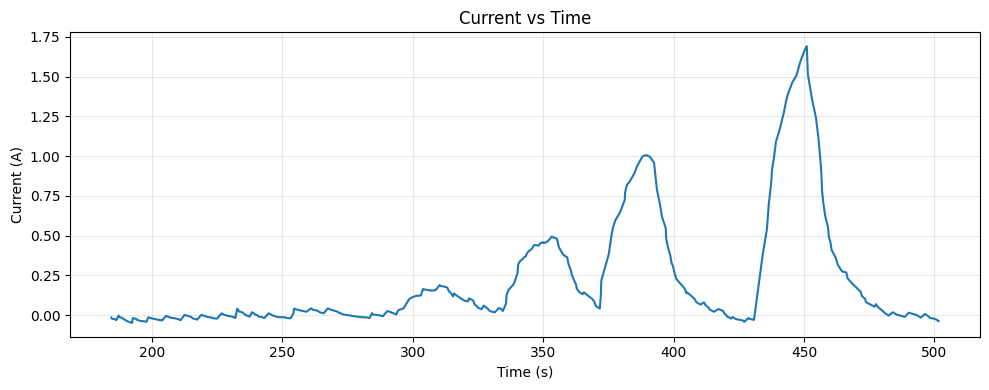

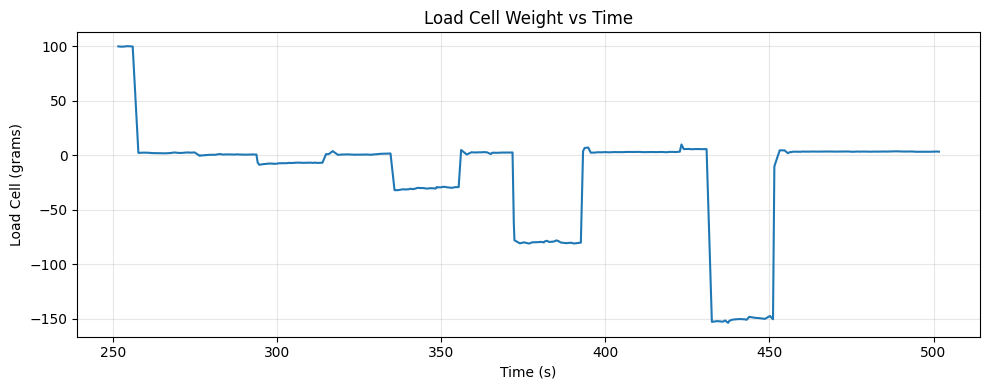

In [ ]:
plot_current_and_thrust(clean_df)


In [ ]:
summary_df = analyze_fixed_run_time(events, raw_df, run_time_s=run_time_s)
summary_df

,Command,Cmd_Time_Str,Start_ms,End_ms,Actual_Window_s,Samples,Avg_Voltage_V,Min_Voltage_V,Max_Voltage_V,Avg_Current_A,Min_Current_A,Max_Current_A,Avg_Thrust_g,Avg_Abs_Thrust_g,Min_Thrust_g,Max_Thrust_g,Peak_Abs_Thrust_g
0,speed 10,21:26:09.833,293700,313700,19.666,28,1.514750,1.510,1.517,0.123500,0.004,0.188,-6.960000,7.007857,-8.72,0.67,8.72
1,speed 20,21:26:50.676,334547,354547,19.628,28,1.523643,1.511,1.530,0.347679,0.026,0.494,-29.237143,29.355000,-32.07,1.65,32.07
2,speed 30,21:27:27.826,371727,391727,19.262,22,1.536955,1.511,1.550,0.674955,0.041,1.006,-75.297727,75.529545,-81.08,2.55,81.08
3,speed 40,21:28:26.966,430847,450847,19.320,17,1.549706,1.509,1.576,0.998294,-0.030,1.662,-141.743529,142.408235,-153.95,5.65,153.95


In [ ]:
def analyze_fixed_run_time(events, raw_df, run_time_s=20.0):
    """
    Analyze each speed command using a fixed run time window.

    Assumption:
    - The motor runs exactly `run_time_s` seconds after each command.
    - So we do NOT detect start/end using threshold.
    - We just take the 20-second window after the command.

    Returns:
    - summary_df
    """
    results = []

    if raw_df.empty:
        return pd.DataFrame()

    run_time_ms = int(run_time_s * 1000)

    for event in events:
        # First data row after command = proxy command time in ms
        segment = raw_df.iloc[event['data_index']:].copy()

        if segment.empty:
            continue

        cmd_proxy_ms = int(segment.iloc[0]['ms'])
        end_ms = cmd_proxy_ms + run_time_ms

        window = segment[
            (segment['ms'] >= cmd_proxy_ms) &
            (segment['ms'] <= end_ms)
        ].copy()

        if window.empty:
            continue

        results.append({
            'Command': f"speed {event['speed']}",
            'Cmd_Time_Str': event['time_str'],
            'Start_ms': cmd_proxy_ms,
            'End_ms': end_ms,
            'Actual_Window_s': (window['ms'].max() - cmd_proxy_ms) / 1000.0,
            'Samples': len(window),

            'Avg_Voltage_V': window['v'].mean(),
            'Min_Voltage_V': window['v'].min(),
            'Max_Voltage_V': window['v'].max(),

            'Avg_Current_A': window['currentA'].mean(),
            'Min_Current_A': window['currentA'].min(),
            'Max_Current_A': window['currentA'].max(),

            'Avg_Thrust_g': window['lc_gram'].mean(),
            'Avg_Abs_Thrust_g': window['lc_gram'].abs().mean(),
            'Min_Thrust_g': window['lc_gram'].min(),
            'Max_Thrust_g': window['lc_gram'].max(),
            'Peak_Abs_Thrust_g': window['lc_gram'].abs().max()
        })

    summary_df = pd.DataFrame(results)
    return summary_df

In [ ]:
def plot_fixed_run_windows(events, raw_df, run_time_s=20.0):
    """
    Plot thrust and highlight each fixed 20-second run window.
    """
    if raw_df.empty:
        print("No raw data to plot.")
        return

    run_time_ms = int(run_time_s * 1000)

    plt.figure(figsize=(14, 6))
    plt.plot(raw_df['ms'], raw_df['lc_gram'], label='Thrust (g)', alpha=0.7)

    for event in events:
        segment = raw_df.iloc[event['data_index']:]

        if segment.empty:
            continue

        start_ms = int(segment.iloc[0]['ms'])
        end_ms = start_ms + run_time_ms

        plt.axvspan(start_ms, end_ms, alpha=0.15, label=f"{event['speed']}% window")

    handles, labels = plt.gca().get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    plt.legend(unique.values(), unique.keys())

    plt.title(f"Motor Runs with Fixed {run_time_s:.0f}-Second Windows")
    plt.xlabel("System Time (ms)")
    plt.ylabel("Thrust (g)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
file_to_analyze = "serial_20260309_212419.txt"
run_time_s = 20.0

In [ ]:
events, raw_df = parse_motor_log(file_to_analyze)
summary_df = analyze_fixed_run_time(events, raw_df, run_time_s=run_time_s)

In [ ]:
summary_df.style.format({
    'Actual_Window_s': '{:.3f}',
    'Avg_Voltage_V': '{:.3f}',
    'Min_Voltage_V': '{:.3f}',
    'Max_Voltage_V': '{:.3f}',
    'Avg_Current_A': '{:.3f}',
    'Min_Current_A': '{:.3f}',
    'Max_Current_A': '{:.3f}',
    'Avg_Thrust_g': '{:.3f}',
    'Avg_Abs_Thrust_g': '{:.3f}',
    'Min_Thrust_g': '{:.3f}',
    'Max_Thrust_g': '{:.3f}',
    'Peak_Abs_Thrust_g': '{:.3f}',
})

,Command,Cmd_Time_Str,Start_ms,End_ms,Actual_Window_s,Samples,Avg_Voltage_V,Min_Voltage_V,Max_Voltage_V,Avg_Current_A,Min_Current_A,Max_Current_A,Avg_Thrust_g,Avg_Abs_Thrust_g,Min_Thrust_g,Max_Thrust_g,Peak_Abs_Thrust_g
0,speed 10,21:26:09.833,293700,313700,19.666,28,1.515,1.510,1.517,0.124,0.004,0.188,-6.960,7.008,-8.720,0.670,8.720
1,speed 20,21:26:50.676,334547,354547,19.628,28,1.524,1.511,1.530,0.348,0.026,0.494,-29.237,29.355,-32.070,1.650,32.070
2,speed 30,21:27:27.826,371727,391727,19.262,22,1.537,1.511,1.550,0.675,0.041,1.006,-75.298,75.530,-81.080,2.550,81.080
3,speed 40,21:28:26.966,430847,450847,19.320,17,1.550,1.509,1.576,0.998,-0.030,1.662,-141.744,142.408,-153.950,5.650,153.950


In [7]:
plot_fixed_run_windows(events, raw_df, run_time_s=run_time_s)

No raw data to plot.
